In [92]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import pyproj
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import mapclassify
import matplotlib.patches as mpatches

In [3]:
scorecard = pd.read_csv("Most-Recent-Cohorts-Institution.csv")

/var/folders/d5/fgntt_0n0bz2jjjxck1hczkh0000gn/T/ipykernel_31169/3257712598.py:1: DtypeWarning: Columns (9,1407,1408,1431,1432,1532,1537,1538,1539,1540,1542,1546,1589,1601,1602,1606,1608,1611,1614,1615,1616,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628,1629,1653,1679,1690,1692,1697,1700,1702,1725,1726,1727,1728,1729,1743,1815,1816,1817,1818,1823,1824,1830,1831,1879,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1909,1910,1911,1912,1913,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1983,1984,2376,2377,2403,2404,2495,2496,2497,2498,2499,2500,2501,2502,2503,2504,2505,2506,2507,2508,2509,2510,2511,2512,2513,2514,2515,2516,2517,2518,2519,2520,2521,2522,2523,2524,2525,2526,2527,2528,2529,2530,2958,3215,3231,3235,3236) have mixed types. Specify dtype option on import or set low_memory=False.
  scorecard = pd.read_csv("Most-Recent-Cohorts-Institution.csv")


In [4]:
needed_cols = ['UNITID', 'INSTNM', 'CITY', 'STABBR', 'ZIP', 'PREDDEG', 'LOCALE', 'LATITUDE', 'LONGITUDE', 'ADM_RATE', 'CONTROL',
               'UGDS_WHITE', 'UGDS_BLACK', 'UGDS_HISP', 'UGDS_ASIAN', 'UGDS_AIAN', 'UGDS_NHPI', 
               'PCTPELL', 
               'DEP_INC_PCT_LO', 'DEP_INC_PCT_M1', 'DEP_INC_PCT_M2', 'DEP_INC_PCT_H1', 'DEP_INC_PCT_H2',
               'MD_EARN_WNE_P10', 'C150_L4', 'C150_4', 'NPT4_PUB', 'NPT4_PRIV']
scorecard = scorecard[needed_cols]
scorecard.columns = ['id', 'school_name', 'city', 'state', 'zipcode', 'predom_degree_awarded', 'locale', 'latitude', 'longitude', 'admit_rate', 'control',
                     'prop_white', 'prop_black', 'prop_hispanic', 'prop_asian', 'prop_aian', 'prop_nhpi',
                     'pell_grant_rate',
                     'pct_lowinc', 'pct_lowmedinc', 'pct_medinc', 'pct_lowhighinc', 'pct_highinc',
                     'median_earnings', 'cc_completion_rate', '4yr_completion_rate', 'net_price_pub', 'net_price_priv']

In [5]:
# drop rows with no location data
scorecard = scorecard.dropna(subset=['latitude', 'longitude'])

# categorize each institution as either broad-access or not
scorecard['is_broad_access'] = (scorecard['admit_rate'] >= 0.75) | (scorecard['admit_rate'].isna())

# filter for community colleges and 4-year universities
scorecard = scorecard[(scorecard['predom_degree_awarded'] == 2) | (scorecard['predom_degree_awarded'] == 3)]

# filter for public and private non-profits
scorecard = scorecard[(scorecard['control'] == 1) | (scorecard['control'] == 2)]

# drop rows in the U.S. territories
scorecard = scorecard[~scorecard['state'].isin(['AS', 'GU', 'MP', 'PR', 'FM', 'PW', 'VI', 'MH'])]

scorecard

,id,school_name,city,state,zipcode,predom_degree_awarded,locale,latitude,longitude,admit_rate,...,pct_lowmedinc,pct_medinc,pct_lowhighinc,pct_highinc,median_earnings,cc_completion_rate,4yr_completion_rate,net_price_pub,net_price_priv,is_broad_access
0,100654,Alabama A & M University,Normal,AL,35762,3,12.0,34.783368,-86.568502,0.6622,...,0.2034134448,PS,PS,PS,40628.0,NaN,0.2874,14559.0,NaN,False
1,100663,University of Alabama at Birmingham,Birmingham,AL,35294-0110,3,12.0,33.505697,-86.799345,0.8842,...,0.1699615596,0.1537616694,0.142778693,0.1847885777,54501.0,NaN,0.6260,17727.0,NaN,True
2,100690,Amridge University,Montgomery,AL,36117-3553,3,12.0,32.362609,-86.174010,NaN,...,PS,PS,PS,PS,37621.0,NaN,0.4000,NaN,NaN,True
3,100706,University of Alabama in Huntsville,Huntsville,AL,35899,3,12.0,34.724557,-86.640449,0.7425,...,0.1448545861,0.1605145414,0.1817673378,0.2438478747,61767.0,NaN,0.6191,19880.0,NaN,False
4,100724,Alabama State University,Montgomery,AL,36104-0271,3,12.0,32.364317,-86.295677,0.9564,...,PS,PS,PS,PS,34502.0,NaN,0.3018,13889.0,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5869,498562,Commonwealth University of Pennsylvania,Bloomsburg,PA,17815,3,32.0,41.007820,-76.447844,0.9475,...,0.1327112494,0.1695178849,PS,PS,52416.0,NaN,0.5302,18877.0,NaN,True
5870,498571,Pennsylvania Western University,California,PA,15419,3,32.0,40.064964,-79.886790,0.9365,...,0.1449932034,0.1921159946,0.1984594472,0.2075215224,47295.0,NaN,0.5103,19352.0,NaN,True
5879,498809,Yeshiva of Kasho,Brooklyn,NY,11231-3819,3,11.0,40.671255,-74.000150,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.1087,NaN,9078.0,True
5889,498906,Yeshivas Sanz Klauzenburg,Brooklyn,NY,11219-3631,3,11.0,40.632725,-73.990129,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.2727,NaN,10556.0,True


In [72]:
scorecard.to_csv("data/scorecard.csv")

In [6]:
# convert to a geodataframe
geometry = [Point(xy) for xy in zip(scorecard['longitude'], scorecard['latitude'])]
schools_gdf = gpd.GeoDataFrame(scorecard, geometry=geometry, crs="EPSG:4326")
schools_gdf

,id,school_name,city,state,zipcode,predom_degree_awarded,locale,latitude,longitude,admit_rate,...,pct_medinc,pct_lowhighinc,pct_highinc,median_earnings,cc_completion_rate,4yr_completion_rate,net_price_pub,net_price_priv,is_broad_access,geometry
0,100654,Alabama A & M University,Normal,AL,35762,3,12.0,34.783368,-86.568502,0.6622,...,PS,PS,PS,40628.0,NaN,0.2874,14559.0,NaN,False,POINT (-86.5685 34.78337)
1,100663,University of Alabama at Birmingham,Birmingham,AL,35294-0110,3,12.0,33.505697,-86.799345,0.8842,...,0.1537616694,0.142778693,0.1847885777,54501.0,NaN,0.6260,17727.0,NaN,True,POINT (-86.79934 33.5057)
2,100690,Amridge University,Montgomery,AL,36117-3553,3,12.0,32.362609,-86.174010,NaN,...,PS,PS,PS,37621.0,NaN,0.4000,NaN,NaN,True,POINT (-86.17401 32.36261)
3,100706,University of Alabama in Huntsville,Huntsville,AL,35899,3,12.0,34.724557,-86.640449,0.7425,...,0.1605145414,0.1817673378,0.2438478747,61767.0,NaN,0.6191,19880.0,NaN,False,POINT (-86.64045 34.72456)
4,100724,Alabama State University,Montgomery,AL,36104-0271,3,12.0,32.364317,-86.295677,0.9564,...,PS,PS,PS,34502.0,NaN,0.3018,13889.0,NaN,True,POINT (-86.29568 32.36432)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5869,498562,Commonwealth University of Pennsylvania,Bloomsburg,PA,17815,3,32.0,41.007820,-76.447844,0.9475,...,0.1695178849,PS,PS,52416.0,NaN,0.5302,18877.0,NaN,True,POINT (-76.44784 41.00782)
5870,498571,Pennsylvania Western University,California,PA,15419,3,32.0,40.064964,-79.886790,0.9365,...,0.1921159946,0.1984594472,0.2075215224,47295.0,NaN,0.5103,19352.0,NaN,True,POINT (-79.88679 40.06496)
5879,498809,Yeshiva of Kasho,Brooklyn,NY,11231-3819,3,11.0,40.671255,-74.000150,NaN,...,NaN,NaN,NaN,NaN,NaN,0.1087,NaN,9078.0,True,POINT (-74.00015 40.67126)
5889,498906,Yeshivas Sanz Klauzenburg,Brooklyn,NY,11219-3631,3,11.0,40.632725,-73.990129,NaN,...,NaN,NaN,NaN,NaN,NaN,0.2727,NaN,10556.0,True,POINT (-73.99013 40.63272)


In [74]:
schools_gdf.to_csv("data/schools_gdf.csv")

In [7]:
county_gdf = gpd.read_file("data/raw-data/cb_2024_us_county_500k/cb_2024_us_county_500k.shp")
county_cols = ['GEOID', 'NAME', 'STUSPS', 'geometry']
county_gdf = county_gdf[county_cols]
county_gdf.columns = ['fips', 'county', 'state', 'geometry']
county_gdf

,fips,county,state,geometry
0,01069,Houston,AL,"POLYGON ((-85.71209 31.19727, -85.70934 31.198..."
1,01023,Choctaw,AL,"POLYGON ((-88.47323 31.89386, -88.46888 31.930..."
2,01113,Russell,AL,"POLYGON ((-85.4347 32.31761, -85.43384 32.3922..."
3,10005,Sussex,DE,"POLYGON ((-75.7226 38.82986, -75.61542 38.8336..."
4,01071,Jackson,AL,"MULTIPOLYGON (((-86.15423 34.53378, -86.14989 ..."
...,...,...,...,...
3230,31161,Sheridan,NE,"POLYGON ((-102.79287 42.82249, -102.79211 42.9..."
3231,17119,Madison,IL,"POLYGON ((-90.27544 38.93482, -90.27503 38.948..."
3232,28155,Webster,MS,"POLYGON ((-89.50714 33.72182, -89.39365 33.721..."
3233,29161,Phelps,MO,"POLYGON ((-92.02856 37.70684, -92.02682 37.707..."


In [8]:
# drop counties in U.S. territories
county_gdf = county_gdf[~county_gdf['state'].isin(['AK', 'HI', 'AS', 'GU', 'MP', 'PR', 'VI'])]

In [79]:
#fig, ax = plt.subplots()
#county_gpd = county_gpd.to_crs("ESRI:102003")
#county_gpd.plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=0.6).set_axis_off()
#county_gpd.centroid.plot(ax=ax, marker='o', markersize=0.4, zorder=3)
#plt.show()

In [16]:
# find the FIPS code for each institution
county_gdf = county_gdf.to_crs("EPSG:4326")

schools_with_fips = gpd.sjoin(schools_gdf, county_gdf[['fips', 'geometry']], how='left', predicate='within')
schools_with_fips = schools_with_fips.drop(columns=['index_right'])

# drop Alaska and Hawaii
schools_with_fips = schools_with_fips[~(schools_with_fips['state'].isin(['AK', 'HI']))]

In [10]:
# collect county FIPS data
fips = pd.read_csv("data/raw-data/State,_County_and_City_FIPS_Reference_Table_20260301.csv")
fips_cols = ['State Name', 'County Name', 'StCnty FIPS Code']
fips = fips[fips_cols]
fips.columns = ['state', 'county', 'fips']

# drop Alaska, Hawaii, and Puerto Rice
fips = fips[~(fips['state'].isin(['ALASKA', 'HAWAII', 'PUERTO RICO']))]

# clean up columns
fips['fips'] = fips['fips'].astype(int).astype(str).str.zfill(5)
fips['state'] = fips['state'].str.title()
fips['county'] = fips['county'].str.title()

fips

,state,county,fips
0,Alabama,Autauga,01001
1,Alabama,Autauga,01001
2,Alabama,Autauga,01001
3,Alabama,Autauga,01001
4,Alabama,Autauga,01001
...,...,...,...
40404,Wyoming,Washakie,56043
40405,Wyoming,Weston,56045
40406,Wyoming,Weston,56045
40407,Wyoming,Weston,56045


In [24]:
# calculate the Opportunity Score for each county

# handle missing earnings data
state_avgs = schools_with_fips.groupby(['state', 'predom_degree_awarded'])['median_earnings'].transform('mean') # finds average earnings for type of school in each state
schools_with_fips['median_earnings'] = schools_with_fips['median_earnings'].fillna(state_avgs)

# get county metrics by FIPS
county_metrics = schools_with_fips.groupby('fips').agg({
    'id':'count',
    'median_earnings':'mean',
    'pell_grant_rate':'mean'
}).rename(columns={
    'id': 'num_institutions',
    'median_earnings': 'median_earnings',
    'pell_grant_rate': 'pell_grant_rate'
})
county_metrics

,num_institutions,median_earnings,pell_grant_rate
fips,,,
01003,2,45075.500000,0.346900
01015,1,45235.000000,0.430900
01047,2,39261.500000,0.183850
01073,6,46249.666667,0.384183
01077,2,44006.000000,0.297400
...,...,...,...
56021,1,44783.000000,0.236100
56025,1,40935.000000,0.233500
56029,1,36950.000000,0.184800


In [26]:
# normalize access
county_metrics['access_score'] = county_metrics['num_institutions'] / county_metrics['num_institutions'].max()

# normalize earnings
min_earnings = county_metrics['median_earnings'].min()
max_earnings = county_metrics['median_earnings'].max()
county_metrics['earnings_score'] = (county_metrics['median_earnings'] - min_earnings) / (max_earnings - min_earnings)

# normalize Pell Grant Rate
min_pgr = county_metrics['pell_grant_rate'].min()
max_pgr = county_metrics['pell_grant_rate'].max()
county_metrics['pell_score'] = (county_metrics['pell_grant_rate'] - min_pgr) / (max_pgr - min_pgr)

# calculate opportunity score (weights: 40% access, 30% earnings, 30% pell/equity)
county_metrics['opportunity_score'] = (
    (county_metrics['access_score'] * 0.4) +
    (county_metrics['earnings_score'] * 0.3) +
    (county_metrics['pell_score'] * 0.3)
) * 100

# handle missing values for opportunity score (counties with no schools)
county_metrics['opportunity_score'] = county_metrics['opportunity_score'].fillna(0)

county_metrics = county_metrics.reset_index()
county_metrics


,fips,num_institutions,median_earnings,pell_grant_rate,access_score,earnings_score,pell_score,opportunity_score
0,01003,2,45075.500000,0.346900,0.031746,0.383614,0.383019,24.268812
1,01015,1,45235.000000,0.430900,0.015873,0.385631,0.475765,26.476794
2,01047,2,39261.500000,0.183850,0.031746,0.310075,0.202992,16.661845
3,01073,6,46249.666667,0.384183,0.095238,0.398465,0.424184,28.488999
4,01077,2,44006.000000,0.297400,0.031746,0.370086,0.328365,22.223366
...,...,...,...,...,...,...,...,...
1098,56021,1,44783.000000,0.236100,0.015873,0.379914,0.260682,19.852811
1099,56025,1,40935.000000,0.233500,0.015873,0.331242,0.257812,18.306533
1100,56029,1,36950.000000,0.184800,0.015873,0.280837,0.204041,15.181273
1101,56033,1,40477.000000,0.174600,0.015873,0.325449,0.192779,16.181763


In [97]:
county_metrics.to_csv("data/derived-data/county_metrics.csv")

In [85]:
county_and_opscore_gdf = county_gdf.merge(county_metrics, on='fips', how='left')
county_with_opscore_gdf = county_and_opscore_gdf.dropna(subset=['opportunity_score'])
county_with_opscore_gdf

,fips,county,state,geometry,num_institutions,median_earnings,pell_grant_rate,access_score,earnings_score,pell_score,opportunity_score
5,01089,Madison,AL,"POLYGON ((837075.135 1319071.827, 836836.572 1...",4.0,47952.0,0.449275,0.063492,0.419997,0.496053,30.021190
11,06079,San Luis Obispo,CA,"POLYGON ((-2243719.665 1716801.604, -2234976.8...",1.0,90768.0,0.183200,0.015873,0.961561,0.202274,35.549980
12,06081,San Mateo,CA,"POLYGON ((-2289521.469 1938898.161, -2289014.0...",5.0,62191.2,0.155475,0.079365,0.600104,0.171663,26.327599
14,08067,La Plata,CO,"POLYGON ((-1088248.745 1622205.605, -1087935.1...",1.0,46349.0,0.361000,0.015873,0.399722,0.398587,24.584174
16,10003,New Castle,DE,"MULTIPOLYGON (((1727469.365 2018516.712, 17275...",4.0,55430.5,0.302475,0.063492,0.514590,0.333968,27.996434
...,...,...,...,...,...,...,...,...,...,...,...
3097,44003,Kent,RI,"POLYGON ((1977965.216 2333488.683, 1983494.009...",2.0,45671.5,0.437300,0.031746,0.391152,0.482831,27.489339
3099,42011,Berks,PA,"POLYGON ((1632474.237 2111196.214, 1632668.046...",5.0,54009.4,0.372280,0.079365,0.496615,0.411041,30.404296
3103,48231,Hunt,TX,"POLYGON ((-27660.427 1088501.835, -27633.643 1...",1.0,50296.0,0.405000,0.015873,0.449646,0.447168,27.539334
3105,17119,Madison,IL,"POLYGON ((491320.867 1782407.332, 491261.269 1...",1.0,56346.0,0.315700,0.015873,0.526170,0.348570,26.877126


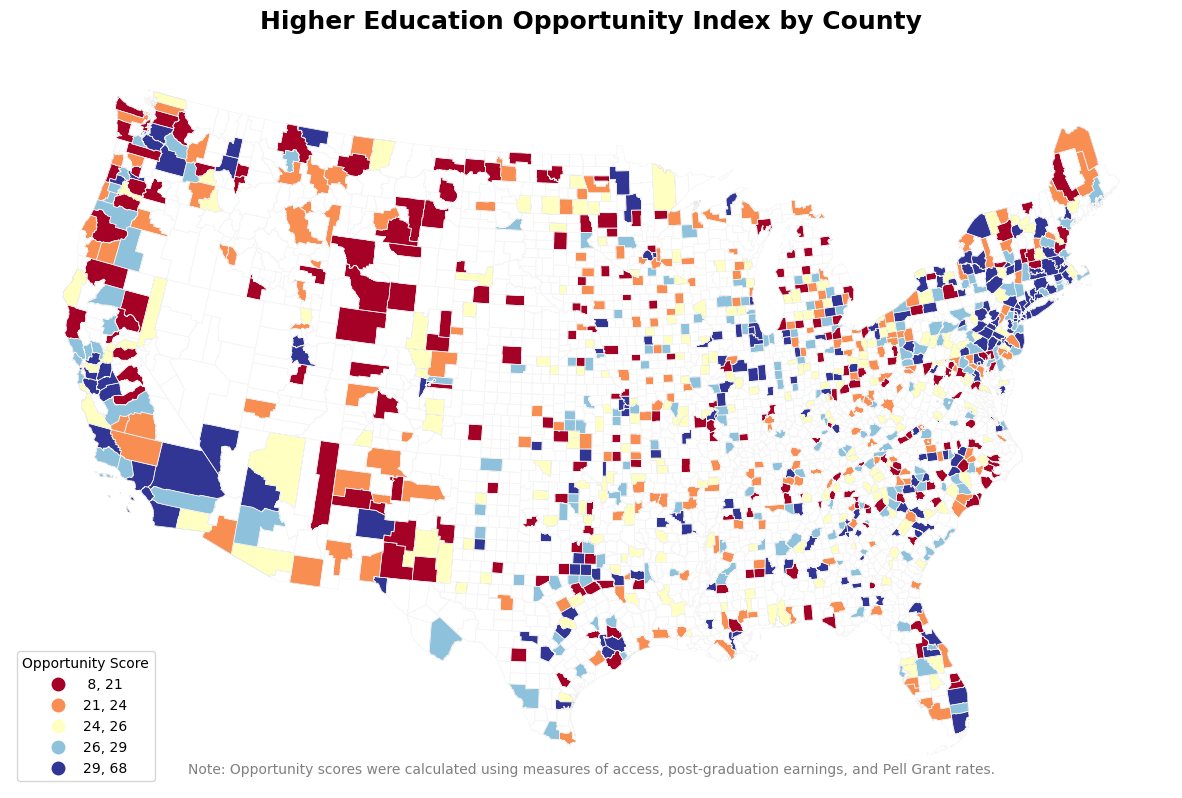

In [ ]:
# use the same CRS
county_with_opscore_gdf = county_with_opscore_gdf.to_crs("EPSG:5070")
schools_with_fips = schools_with_fips.to_crs("EPSG:5070")
county_gdf = county_gdf.to_crs("EPSG:5070")

# initialize the plot
fig, ax = plt.subplots(figsize=(15, 10))

# plot the base map
county_gdf.boundary.plot(ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5)

# color the counties by opportunity score
county_with_opscore_gdf.plot(
    column='opportunity_score',
    ax=ax,
    cmap='RdYlBu',
    scheme='Quantiles',
    k=5, 
    legend=True,
    legend_kwds={
        'title': "Opportunity Score",
        'loc': 'lower left',
        'fmt': "{:.0f}"
    },
    edgecolor='black',
    linewidth=0.1
)

# add title
plt.title("Higher Education Opportunity Index by County", fontsize=18, fontweight='bold', pad=20)
ax.set_axis_off()

# add a note for context
plt.text(0.5, 0.02, "Note: Opportunity scores were calculated using measures of access, post-graduation earnings, and Pell Grant rates.", 
         transform=ax.transAxes, ha="center", fontsize=10, color='gray')

plt.show()

In [88]:
county_and_opscore_gdf[county_and_opscore_gdf['opportunity_score'].isna()]

,fips,county,state,geometry,num_institutions,median_earnings,pell_grant_rate,access_score,earnings_score,pell_score,opportunity_score
0,01069,Houston,AL,"POLYGON ((975267.981 955249.146, 975512.945 95...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01023,Choctaw,AL,"POLYGON ((708032.013 1008009.585, 708119.103 1...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01113,Russell,AL,"POLYGON ((987614.299 1082134.819, 986771.184 1...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10005,Sussex,DE,"POLYGON ((1730705.501 1941185.697, 1739623.244...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01071,Jackson,AL,"MULTIPOLYGON (((895011.35 1321054.818, 895405....",NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
3101,27159,Wadena,MN,"POLYGON ((64164.189 2634293.057, 64173.06 2636...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3102,01079,Lawrence,AL,"POLYGON ((771041.147 1300508.788, 770941.299 1...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3104,31161,Sheridan,NE,"POLYGON ((-551780.743 2222598.709, -550303.118...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3106,28155,Webster,MS,"POLYGON ((597014.788 1204295.641, 607433.752 1...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


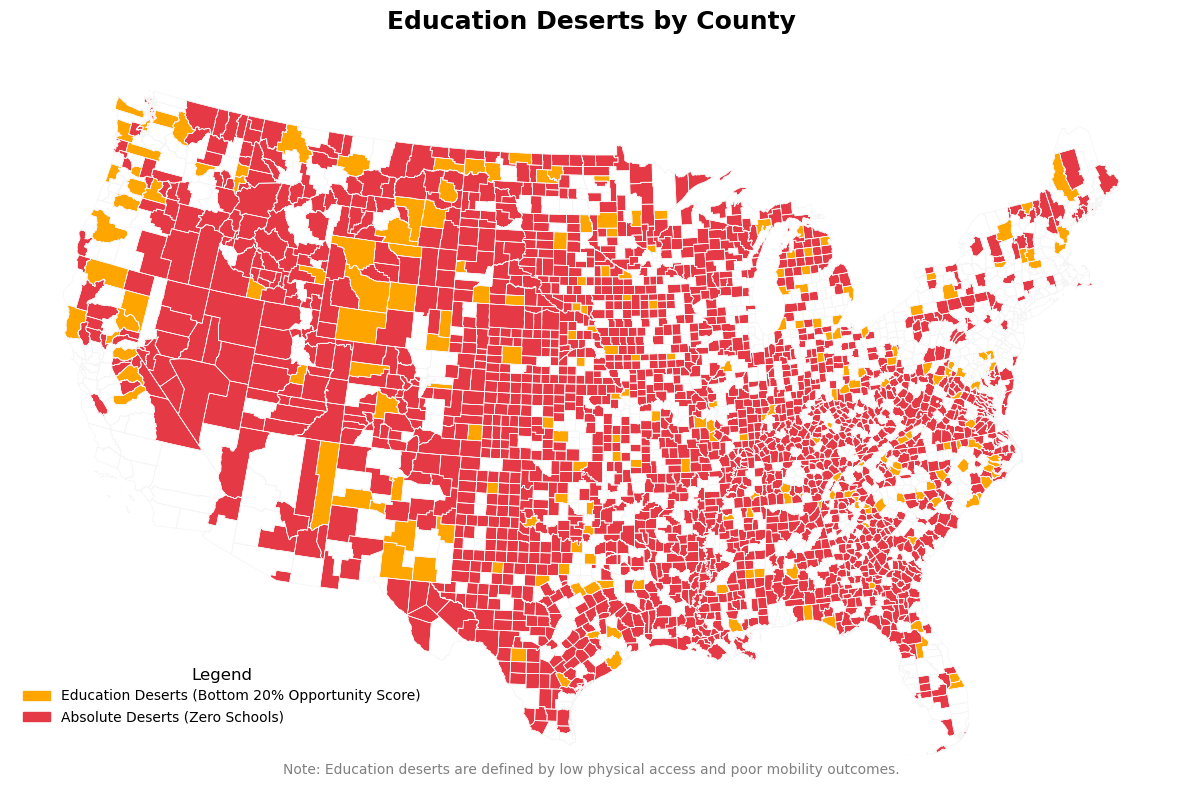

In [ ]:
# highlight the education deserts

# get the counties with zero schools
county_withno_opscore_gdf = county_and_opscore_gdf[county_and_opscore_gdf['opportunity_score'].isna()]

# identify the bottom 20% of counties with the lowest opportunity scores
threshold = county_and_opscore_gdf['opportunity_score'].quantile(0.20)
deserts_gdf = county_and_opscore_gdf[county_and_opscore_gdf['opportunity_score'] <= threshold]

# initialize the plot
fig, ax = plt.subplots(figsize=(15, 10))

# plot the base map
county_gdf.boundary.plot(ax=ax, color='whitesmoke', edgecolor='lightgrey', linewidth=0.5)

# plot the deserts
deserts_gdf.plot(ax=ax, color='orange', edgecolor='white', linewidth=0.2, label='Education Deserts (Bottom 20% Opportunity Score)')
county_withno_opscore_gdf.plot(ax=ax, color='#e63946', edgecolor='white', linewidth=0.2, label='Absolute Deserts (Zero Schools)')

# add a legend
red_patch = mpatches.Patch(color='orange', label='Education Deserts (Bottom 20% Opportunity Score)')
orange_patch = mpatches.Patch(color='#e63946', label='Absolute Deserts (Zero Schools)')

ax.legend(
    handles=[red_patch, orange_patch], 
    loc='lower left',
    bbox_to_anchor=(0, 0.07), # offsets position of legend from loc input
    fontsize=10, 
    title='Legend', 
    title_fontsize=12, 
    frameon=False
)

# add title
plt.title("Education Deserts by County", fontsize=18, fontweight='bold', pad=20)

# add a note for context
plt.text(0.5, 0.02, 'Note: Education deserts are defined by low physical access and poor mobility outcomes.', 
         transform=ax.transAxes, ha="center", fontsize=10, color='gray')

ax.set_axis_off()
plt.show()
